# Regression Model Comparison

In this notebook, we will compare multiple regression algorithms
on the same dataset.

The goal is to determine which model performs best for our dataset.

We will compare models using:

- MAE
- MSE
- RMSE
- R² Score
- Training Time

Models:

1. Linear Regression
2. KNN Regressor
3. Decision Tree Regressor
4. Random Forest Regressor
5. SVR
6. Gradient Boosting Regressor
7. Extra Trees Regressor
8. XGBoost Regressor
9. LightGBM Regressor
10. CatBoost Regressor

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import time

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.svm import SVR

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [6]:
X = df[
    [
        "total_bill",
        "size"
    ]
]

y = df["tip"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
models = {

    "Linear Regression": LinearRegression(),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "SVR": SVR(
        kernel="rbf",
        C=1.0
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=100,
        learning_rate=0.1,
        depth=4,
        random_seed=42,
        verbose=False
    )
}

In [9]:
results = []

for name, model in models.items():

    # Start timer
    start_time = time.time()

    # Train
    model.fit(
        X_train,
        y_train
    )

    # Predictions
    y_pred = model.predict(
        X_test
    )

    # End timer
    training_time = time.time() - start_time

    # Metrics
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Training Time": training_time
    })

In [10]:
results_df = pd.DataFrame(
    results
)

results_df

,Model,MAE,MSE,RMSE,R2,Training Time
0,Linear Regression,0.663924,0.648600,0.805357,0.481108,0.068000
1,KNN,0.721143,0.743658,0.862356,0.405060,0.029000
2,Decision Tree,0.817755,1.004704,1.002349,0.196218,0.001000
3,Random Forest,0.736765,0.834279,0.913389,0.332562,0.061000
4,SVR,0.560650,0.534742,0.731260,0.572197,0.006999
5,Gradient Boosting,0.689645,0.800605,0.894765,0.359502,0.030001
6,Extra Trees,0.702594,0.798212,0.893427,0.361416,0.046999
7,XGBoost,0.644493,0.627261,0.791998,0.498179,0.125999
8,LightGBM,0.643903,0.615262,0.784386,0.507779,1.309415
9,CatBoost,0.641487,0.645998,0.803740,0.483190,0.193031


In [11]:
results_df.sort_values(
    by="RMSE",
    ascending=True
)

,Model,MAE,MSE,RMSE,R2,Training Time
4,SVR,0.560650,0.534742,0.731260,0.572197,0.006999
8,LightGBM,0.643903,0.615262,0.784386,0.507779,1.309415
7,XGBoost,0.644493,0.627261,0.791998,0.498179,0.125999
9,CatBoost,0.641487,0.645998,0.803740,0.483190,0.193031
0,Linear Regression,0.663924,0.648600,0.805357,0.481108,0.068000
1,KNN,0.721143,0.743658,0.862356,0.405060,0.029000
6,Extra Trees,0.702594,0.798212,0.893427,0.361416,0.046999
5,Gradient Boosting,0.689645,0.800605,0.894765,0.359502,0.030001
3,Random Forest,0.736765,0.834279,0.913389,0.332562,0.061000
2,Decision Tree,0.817755,1.004704,1.002349,0.196218,0.001000


In [12]:
results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2,Training Time
4,SVR,0.560650,0.534742,0.731260,0.572197,0.006999
8,LightGBM,0.643903,0.615262,0.784386,0.507779,1.309415
7,XGBoost,0.644493,0.627261,0.791998,0.498179,0.125999
9,CatBoost,0.641487,0.645998,0.803740,0.483190,0.193031
0,Linear Regression,0.663924,0.648600,0.805357,0.481108,0.068000
1,KNN,0.721143,0.743658,0.862356,0.405060,0.029000
6,Extra Trees,0.702594,0.798212,0.893427,0.361416,0.046999
5,Gradient Boosting,0.689645,0.800605,0.894765,0.359502,0.030001
3,Random Forest,0.736765,0.834279,0.913389,0.332562,0.061000
2,Decision Tree,0.817755,1.004704,1.002349,0.196218,0.001000


In [13]:
best_rmse_model = results_df.loc[
    results_df["RMSE"].idxmin()
]

print("Best model according to RMSE:")
print(best_rmse_model)

Best model according to RMSE:
Model                 SVR
MAE               0.56065
MSE              0.534742
RMSE              0.73126
R2               0.572197
Training Time    0.006999
Name: 4, dtype: object


In [14]:
best_r2_model = results_df.loc[
    results_df["R2"].idxmax()
]

print("Best model according to R²:")
print(best_r2_model)

Best model according to R²:
Model                 SVR
MAE               0.56065
MSE              0.534742
RMSE              0.73126
R2               0.572197
Training Time    0.006999
Name: 4, dtype: object


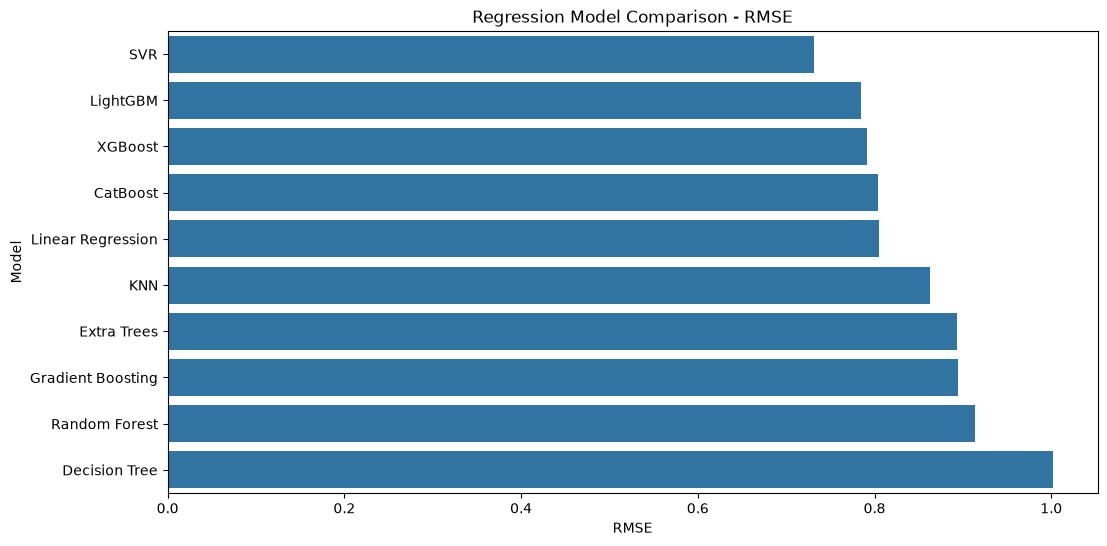

In [15]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df.sort_values("RMSE"),
    x="RMSE",
    y="Model"
)

plt.title("Regression Model Comparison - RMSE")

plt.show()

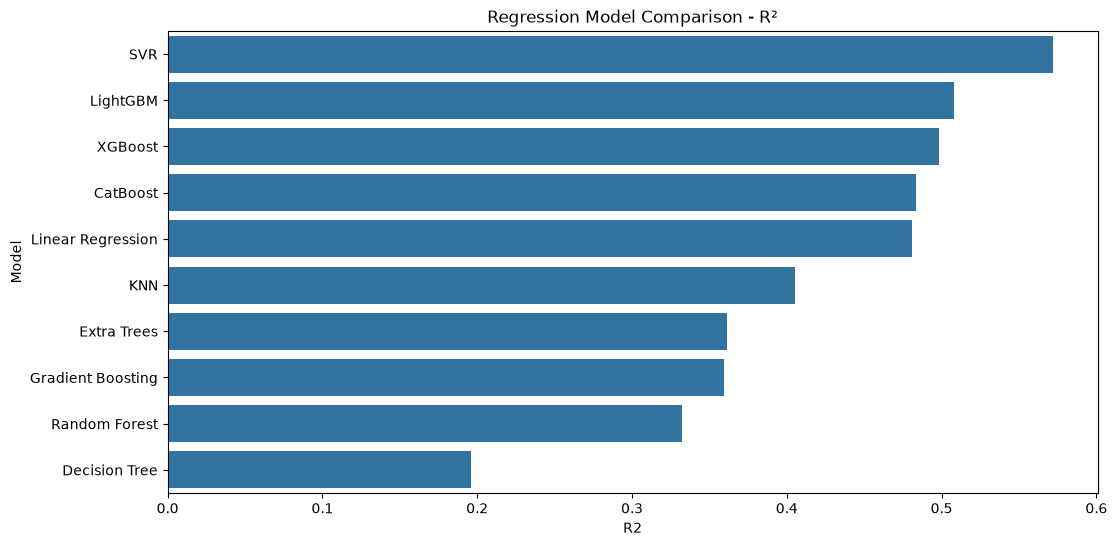

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df.sort_values(
        "R2",
        ascending=False
    ),
    x="R2",
    y="Model"
)

plt.title("Regression Model Comparison - R²")

plt.show()

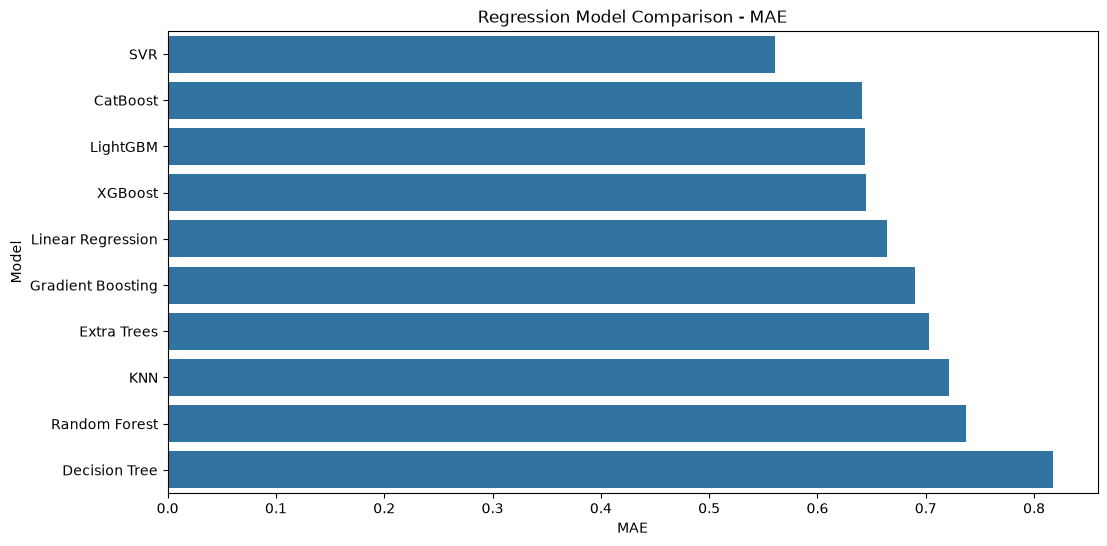

In [17]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df.sort_values("MAE"),
    x="MAE",
    y="Model"
)

plt.title("Regression Model Comparison - MAE")

plt.show()

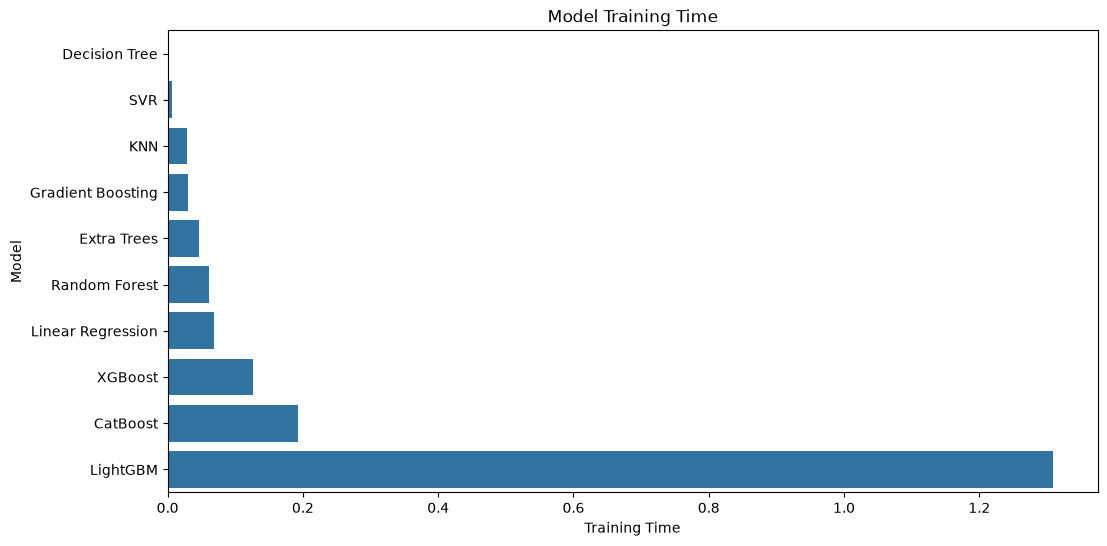

In [18]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df.sort_values(
        "Training Time"
    ),
    x="Training Time",
    y="Model"
)

plt.title("Model Training Time")

plt.show()

In [19]:
best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: SVR


In [20]:
best_model = models[
    best_model_name
]

In [21]:
best_predictions = best_model.predict(
    X_test
)

In [22]:
actual_vs_predicted = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions
})

actual_vs_predicted.head(10)

,Actual,Predicted
0,3.18,3.102027
1,2.00,1.629913
2,2.00,3.775377
3,5.16,3.876287
4,2.00,2.109123
5,2.00,2.840086
6,2.56,3.808848
7,2.52,2.036574
8,3.23,2.372472
9,3.00,2.463977


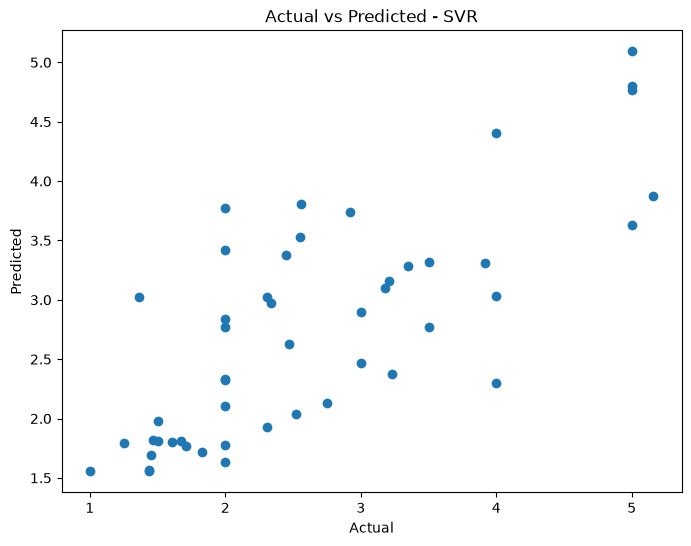

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title(
    f"Actual vs Predicted - {best_model_name}"
)

plt.show()

In [24]:
residuals = y_test - best_predictions

residuals.head()

24     0.077973
6      0.370087
153   -1.775377
211    1.283713
198   -0.109123
Name: tip, dtype: float64

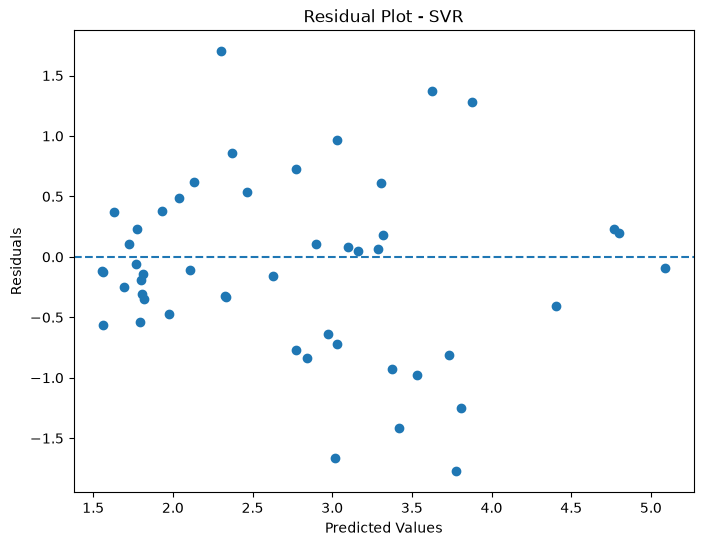

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    best_predictions,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title(
    f"Residual Plot - {best_model_name}"
)

plt.show()

# Choosing the Evaluation Metric

MAE:
→ Easy to understand.
→ Less sensitive to large errors.

MSE:
→ Penalizes large errors more heavily.
→ Units are squared.

RMSE:
→ Penalizes large errors.
→ Same units as the target.
→ Very commonly used for regression.

R²:
→ Measures how much variance is explained by the model.
→ Higher is generally better.

Training Time:
→ Shows computational cost.

In [26]:
ranking = results_df.copy()

ranking["RMSE Rank"] = ranking[
    "RMSE"
].rank(
    ascending=True
)

ranking["R2 Rank"] = ranking[
    "R2"
].rank(
    ascending=False
)

ranking = ranking.sort_values(
    "RMSE Rank"
)

ranking

,Model,MAE,MSE,RMSE,R2,Training Time,RMSE Rank,R2 Rank
4,SVR,0.560650,0.534742,0.731260,0.572197,0.006999,1.0,1.0
8,LightGBM,0.643903,0.615262,0.784386,0.507779,1.309415,2.0,2.0
7,XGBoost,0.644493,0.627261,0.791998,0.498179,0.125999,3.0,3.0
9,CatBoost,0.641487,0.645998,0.803740,0.483190,0.193031,4.0,4.0
0,Linear Regression,0.663924,0.648600,0.805357,0.481108,0.068000,5.0,5.0
1,KNN,0.721143,0.743658,0.862356,0.405060,0.029000,6.0,6.0
6,Extra Trees,0.702594,0.798212,0.893427,0.361416,0.046999,7.0,7.0
5,Gradient Boosting,0.689645,0.800605,0.894765,0.359502,0.030001,8.0,8.0
3,Random Forest,0.736765,0.834279,0.913389,0.332562,0.061000,9.0,9.0
2,Decision Tree,0.817755,1.004704,1.002349,0.196218,0.001000,10.0,10.0


In [27]:
final_ranking = ranking[
    [
        "Model",
        "RMSE",
        "R2",
        "MAE",
        "Training Time",
        "RMSE Rank",
        "R2 Rank"
    ]
]

final_ranking

,Model,RMSE,R2,MAE,Training Time,RMSE Rank,R2 Rank
4,SVR,0.731260,0.572197,0.560650,0.006999,1.0,1.0
8,LightGBM,0.784386,0.507779,0.643903,1.309415,2.0,2.0
7,XGBoost,0.791998,0.498179,0.644493,0.125999,3.0,3.0
9,CatBoost,0.803740,0.483190,0.641487,0.193031,4.0,4.0
0,Linear Regression,0.805357,0.481108,0.663924,0.068000,5.0,5.0
1,KNN,0.862356,0.405060,0.721143,0.029000,6.0,6.0
6,Extra Trees,0.893427,0.361416,0.702594,0.046999,7.0,7.0
5,Gradient Boosting,0.894765,0.359502,0.689645,0.030001,8.0,8.0
3,Random Forest,0.913389,0.332562,0.736765,0.061000,9.0,9.0
2,Decision Tree,1.002349,0.196218,0.817755,0.001000,10.0,10.0


# Important Model Selection Rule

We should NOT select a model only because it has the highest R².

We should consider:

1. RMSE
2. MAE
3. R²
4. Cross-validation performance
5. Training time
6. Model complexity
7. Overfitting
8. Dataset size
9. Interpretability

A model with the highest test score is not automatically the best
model for a real-world project.

In [28]:
from sklearn.model_selection import cross_val_score

In [29]:
cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    rmse_scores = -scores

    cv_results.append({
        "Model": name,
        "Mean CV RMSE": rmse_scores.mean(),
        "Std CV RMSE": rmse_scores.std()
    })

In [30]:
cv_df = pd.DataFrame(
    cv_results
)

cv_df.sort_values(
    "Mean CV RMSE"
)

,Model,Mean CV RMSE,Std CV RMSE
0,Linear Regression,1.000535,0.205875
4,SVR,1.045394,0.235965
9,CatBoost,1.052291,0.165120
8,LightGBM,1.099766,0.252544
7,XGBoost,1.126404,0.149200
1,KNN,1.132711,0.216642
5,Gradient Boosting,1.144859,0.139056
3,Random Forest,1.190065,0.180198
6,Extra Trees,1.319222,0.190454
2,Decision Tree,1.431300,0.180036


# Why Cross-Validation?

A single train-test split can sometimes give us a misleading result.

Example:

Split 1 → Model performs very well

But perhaps that split was lucky.

Cross-validation:

Fold 1 → Train / Validation
Fold 2 → Train / Validation
Fold 3 → Train / Validation
Fold 4 → Train / Validation
Fold 5 → Train / Validation

Then:

Average Performance
        ↓
More reliable estimate

In [31]:
final_comparison = results_df[
    [
        "Model",
        "RMSE",
        "R2"
    ]
].merge(
    cv_df,
    on="Model"
)

final_comparison.sort_values(
    "Mean CV RMSE"
)

,Model,RMSE,R2,Mean CV RMSE,Std CV RMSE
0,Linear Regression,0.805357,0.481108,1.000535,0.205875
4,SVR,0.731260,0.572197,1.045394,0.235965
9,CatBoost,0.803740,0.483190,1.052291,0.165120
8,LightGBM,0.784386,0.507779,1.099766,0.252544
7,XGBoost,0.791998,0.498179,1.126404,0.149200
1,KNN,0.862356,0.405060,1.132711,0.216642
5,Gradient Boosting,0.894765,0.359502,1.144859,0.139056
3,Random Forest,0.913389,0.332562,1.190065,0.180198
6,Extra Trees,0.893427,0.361416,1.319222,0.190454
2,Decision Tree,1.002349,0.196218,1.431300,0.180036


# Final Conclusion

We compared multiple regression algorithms:

- Linear Regression
- KNN Regression
- Decision Tree Regression
- Random Forest Regression
- SVR
- Gradient Boosting
- Extra Trees
- XGBoost
- LightGBM
- CatBoost

We evaluated them using:

- MAE
- MSE
- RMSE
- R²
- Training Time
- Cross-Validation RMSE

Important conclusions:

1. No single algorithm is always the best.

2. Tree-based ensemble models can perform very well on tabular data.

3. Linear Regression is simple and highly interpretable.

4. KNN can work well for smaller datasets but is sensitive to feature
   scaling.

5. Decision Trees can easily overfit.

6. Random Forest and Extra Trees reduce the weaknesses of individual
   Decision Trees.

7. Gradient Boosting, XGBoost, LightGBM and CatBoost can provide
   powerful predictions.

8. Cross-validation provides a more reliable estimate of model
   performance.

9. The best model should be selected based on both performance and
   real-world requirements.